# Workout LGD EDA

LGD development begins with actual defaults, EAD at default and discounted net recoveries.

In [1]:
from pathlib import Path
import json
import sqlite3
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if not (ROOT / "config").exists():
    ROOT = ROOT.parent
DB = ROOT / "database" / "ifrs9_ecl.sqlite3"

def query(sql):
    with sqlite3.connect(DB) as connection:
        return pd.read_sql_query(sql, connection)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams["figure.figsize"] = (9, 4)

In [2]:
recoveries = query('select * from default_workout_recovery')
for column in ['ead_at_default','workout_lgd','recovery_duration_months','estimated_ltv_at_default']:
    recoveries[column] = pd.to_numeric(recoveries[column], errors='coerce')
recoveries.shape

(608, 32)

In [3]:
recoveries.groupby('completed_workout').agg(
defaults=('loan_id','count'), ead=('ead_at_default','sum'),
average_lgd=('workout_lgd','mean'), median_lgd=('workout_lgd','median'),
average_duration=('recovery_duration_months','mean'))

,defaults,ead,average_lgd,median_lgd,average_duration
completed_workout,,,,,
0,283,"52,829,027.3500",0.0696,0.0639,41.9118
1,325,"63,293,202.1100",0.1020,0.0607,19.9138


Text(0.5, 1.0, 'Completed-workout LGD')

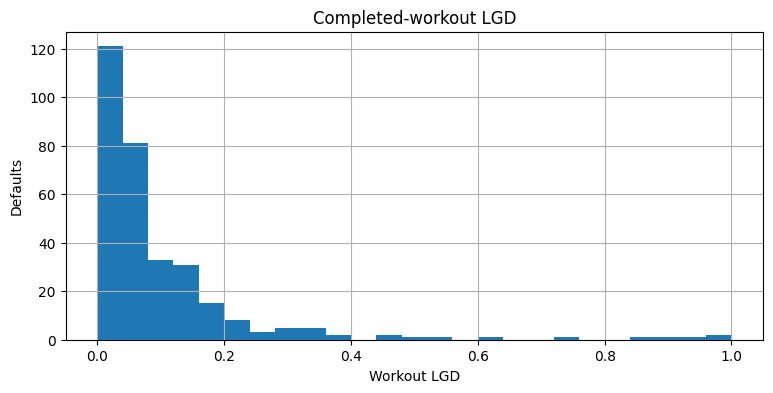

In [4]:
recoveries.loc[recoveries.completed_workout.eq(1),'workout_lgd'].hist(bins=25)
plt.xlabel('Workout LGD'); plt.ylabel('Defaults'); plt.title('Completed-workout LGD')

In [5]:
recoveries[['ead_at_default','estimated_ltv_at_default','workout_lgd','recovery_duration_months']].corr()

,ead_at_default,estimated_ltv_at_default,workout_lgd,recovery_duration_months
ead_at_default,1.0000,0.2666,-0.1495,-0.0838
estimated_ltv_at_default,0.2666,1.0000,0.2033,0.0603
workout_lgd,-0.1495,0.2033,1.0000,0.3866
recovery_duration_months,-0.0838,0.0603,0.3866,1.0000


Incomplete workouts remain identified as model estimates and are not mixed silently with completed recoveries.